In [1]:
import pandas as pd
import numpy as np
import os
import csv

# ============================================================
# CONFIGURACIÓN
# ============================================================
datos_originales = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\ENAHO"
base_resultados = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2"
os.makedirs(base_resultados, exist_ok=True)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def encontrar_archivo(carpeta, inicio_nombre):
    for f in os.listdir(carpeta):
        if f.upper().replace(".CSV", "").startswith(inicio_nombre.upper()):
            return os.path.join(carpeta, f)
    raise FileNotFoundError(f"No se encontró {inicio_nombre} en {carpeta}")

def leer_csv_inei_robusto(ruta):
    """Lee archivos CSV de INEI con diferentes configuraciones"""
    separadores = [",", ";", "\t", "|"]
    encodings = ["utf-8-sig", "latin1", "utf-8", "cp1252", "iso-8859-1"]
    
    for sep in separadores:
        for enc in encodings:
            try:
                df = pd.read_csv(ruta, sep=sep, encoding=enc, low_memory=False, 
                                dtype=str, on_bad_lines='skip')
                if len(df.columns) > 1:
                    df.columns = df.columns.str.strip()
                    if len(df.columns) > 5:
                        print(f"  ✓ Leído con sep='{sep}', encoding='{enc}'")
                        return df
            except Exception:
                continue
    
    # Si falla, intentar con csv.Sniffer
    try:
        with open(ruta, 'r', encoding='latin1') as f:
            sample = f.read(1024)
            f.seek(0)
            sniffer = csv.Sniffer()
            delimiter = sniffer.sniff(sample).delimiter
            df = pd.read_csv(ruta, sep=delimiter, encoding='latin1', 
                            low_memory=False, dtype=str, on_bad_lines='skip')
            df.columns = df.columns.str.strip()
            return df
    except Exception:
        pass
    
    raise ValueError(f"No se pudo leer el archivo: {ruta}")

def to_num(serie):
    if serie.dtype == 'object':
        serie = serie.str.replace(',', '.', regex=False)
    return pd.to_numeric(serie, errors="coerce")

def construir_llave_persona(df, llaves=None, nombre="llave_persona"):
    if llaves is None:
        llaves = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    df = df.copy()
    for c in llaves:
        df[f"_{c}_k"] = pd.to_numeric(df[c], errors="coerce").astype("Int64").astype(str)
    df[nombre] = df[[f"_{c}_k" for c in llaves]].agg("-".join, axis=1)
    return df.drop(columns=[f"_{c}_k" for c in llaves])

# ============================================================
# COLUMNAS PARA USO DE BILLETERA
# ============================================================
COLS_USO_BILLETERA = [f"P558H{i}_7" for i in range(1, 13)]

def reparar_variables(df):
    df = df.copy()

    df["Edad"] = to_num(df["P208A"]) if "P208A" in df.columns else df.get("Edad")
    df["P507_num"] = to_num(df["P507"])
    df["P510A1_num"] = to_num(df["P510A1"])
    df["P511A_num"] = to_num(df["P511A"])

    df["Ocupado"] = df["P507_num"].notna().astype(int)

    tfnr = df["P507_num"] == 5
    trab_hogar = df["P507_num"] == 6
    sin_sunat = (df["P507_num"] == 2) & (df["P510A1_num"] == 3)
    dependiente = df["P507_num"].isin([3, 4])
    sin_contrato = df["P511A_num"] == 7

    df["Informal"] = (
        sin_sunat.fillna(False)
        | tfnr.fillna(False)
        | trab_hogar.fillna(False)
        | (dependiente & sin_contrato.fillna(False))
    ).astype(int)
    df.loc[df["Ocupado"] == 0, "Informal"] = pd.NA

    df["P558E1_4"] = to_num(df.get("P558E1_4")).fillna(0)
    df["P558E1_9"] = to_num(df.get("P558E1_9")).fillna(0)
    df["CreditoFormal"] = ((df["P558E1_4"] == 4) | (df["P558E1_9"] == 9)).astype(int)

    df["P558E1_8"] = to_num(df.get("P558E1_8")).fillna(0)
    df["TenenciaBilletera"] = (df["P558E1_8"] == 8).astype(int)

    cols_uso_presentes = [c for c in COLS_USO_BILLETERA if c in df.columns]
    if cols_uso_presentes:
        uso_flags = pd.concat(
            [to_num(df[c]).fillna(0) == 7 for c in cols_uso_presentes], axis=1
        )
        df["UsoBilletera"] = uso_flags.any(axis=1).astype(int)
    else:
        df["UsoBilletera"] = pd.NA

    if "P558G7" in df.columns:
        df["CreditoInformal"] = (to_num(df["P558G7"]).fillna(0) == 7).astype(int)

    # ============================================================
    # NUEVO: P558F1B - Razón por la que NO tiene préstamo/tarjeta
    # ============================================================
    if "P558F1B" in df.columns:
        df["RazonNoCredito"] = to_num(df["P558F1B"])
        # Crear dummies para cada categoría
        df["Razon_Demanda"] = (df["RazonNoCredito"] == 6).astype(int)      # No necesita / No le interesa
        df["Razon_Deuda"] = (df["RazonNoCredito"] == 7).astype(int)        # Ya tiene deuda
        df["Razon_Intereses"] = (df["RazonNoCredito"] == 8).astype(int)    # Intereses muy altos
        df["Razon_Costos"] = (df["RazonNoCredito"] == 9).astype(int)       # Servicios costosos
        df["Razon_Requisitos"] = (df["RazonNoCredito"] == 10).astype(int)  # Requisitos que no tiene
        df["Razon_Infocorp"] = (df["RazonNoCredito"] == 11).astype(int)    # Está en INFOCORP
        df["Razon_Otro"] = (df["RazonNoCredito"] == 12).astype(int)        # Otro
        
        # Variable de "barrera de acceso" (cualquier razón excepto "no necesita")
        df["tiene_barrera_credito"] = (~df["RazonNoCredito"].isin([6, np.nan])).astype(int)
        
        print(f"  ✓ P558F1B procesada: {df['RazonNoCredito'].notna().sum():,} respuestas")
        print(f"    - Demanda (no necesita): {df['Razon_Demanda'].sum():,}")
        print(f"    - Barreras (intereses, requisitos, Infocorp): {df['tiene_barrera_credito'].sum():,}")
    else:
        df["RazonNoCredito"] = pd.NA
        df["Razon_Demanda"] = pd.NA
        df["Razon_Deuda"] = pd.NA
        df["Razon_Intereses"] = pd.NA
        df["Razon_Costos"] = pd.NA
        df["Razon_Requisitos"] = pd.NA
        df["Razon_Infocorp"] = pd.NA
        df["Razon_Otro"] = pd.NA
        df["tiene_barrera_credito"] = pd.NA

    return df

def construir_master(anio, carpetas):
    print(f"\n{'='*60}")
    print(f"CARGANDO MÓDULOS {anio}")
    print(f"{'='*60}")

    print("\n📂 Leyendo Módulo 200...")
    ruta_200 = encontrar_archivo(*carpetas["Mod200"])
    df200 = leer_csv_inei_robusto(ruta_200)
    cols_200 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P203", "P207", "P208A"]
    df200 = df200[[c for c in cols_200 if c in df200.columns]]
    print(f"  ✓ {len(df200):,} filas")

    print("\n📂 Leyendo Módulo 300...")
    ruta_300 = encontrar_archivo(*carpetas["Mod300"])
    df300 = leer_csv_inei_robusto(ruta_300)
    cols_300 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO", "P301A", "P301B"]
    df300 = df300[[c for c in cols_300 if c in df300.columns]]
    print(f"  ✓ {len(df300):,} filas")

    print("\n📂 Leyendo Módulo 500...")
    ruta_500 = encontrar_archivo(*carpetas["Mod500"])
    df500_full = leer_csv_inei_robusto(ruta_500)
    
    # ============================================================
    # MODIFICACIÓN: AGREGAR P558F1B
    # ============================================================
    cols_500 = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO",
                "P507", "P510A1", "P511A", "P512A",
                "P558E1_4", "P558E1_8", "P558E1_9", "P558G7",
                "P558F1B"] + COLS_USO_BILLETERA
    
    df500 = df500_full[[c for c in cols_500 if c in df500_full.columns]]
    print(f"  ✓ {len(df500):,} filas")
    print(f"  ✓ P558F1B incluida: {'P558F1B' in df500.columns}")

    print("\n📂 Leyendo Módulo 100...")
    ruta_100 = encontrar_archivo(*carpetas["Mod100"])
    df100 = leer_csv_inei_robusto(ruta_100)
    cols_100 = ["CONGLOME", "VIVIENDA", "HOGAR", "DOMINIO", "ESTRATO", "PANEL"]
    for fac in ["FACTOR", "FACPOB", "FACTOR07"]:
        if fac in df100.columns:
            cols_100.append(fac)
            break
    df100 = df100[[c for c in cols_100 if c in df100.columns]]
    print(f"  ✓ {len(df100):,} filas")

    print("\n📂 Leyendo Sumaria...")
    ruta_sum = encontrar_archivo(*carpetas["Sumaria"])
    df_sum = leer_csv_inei_robusto(ruta_sum)
    print(f"  ✓ {len(df_sum):,} filas x {len(df_sum.columns)} columnas")
    
    cols_sum = ["CONGLOME", "VIVIENDA", "HOGAR"]
    
    ingreso_col = None
    gasto_col = None
    
    for col in ["INGHOG2D", "INGHOG1D", "INGHOG2", "INGHOG1"]:
        if col in df_sum.columns:
            ingreso_col = col
            break
    
    for col in ["GASHOG2D", "GASHOG1D", "GASHOG2", "GASHOG1"]:
        if col in df_sum.columns:
            gasto_col = col
            break
    
    if ingreso_col:
        df_sum = df_sum.rename(columns={ingreso_col: "INGHOG2D"})
        cols_sum.append("INGHOG2D")
        print(f"  ✓ Ingreso encontrado: {ingreso_col} → INGHOG2D")
    
    if gasto_col:
        df_sum = df_sum.rename(columns={gasto_col: "GASHOG2D"})
        cols_sum.append("GASHOG2D")
        print(f"  ✓ Gasto encontrado: {gasto_col} → GASHOG2D")
    
    for m in ["MIEPERHO", "MIEMBRO"]:
        if m in df_sum.columns:
            cols_sum.append(m)
            break
    
    df_sum = df_sum[cols_sum]

    print("\n🔗 Realizando merges...")
    llave_persona = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
    llave_hogar = ["CONGLOME", "VIVIENDA", "HOGAR"]

    df = df200.merge(df300, on=llave_persona, how="left")
    print(f"  ✓ Merge 200+300: {len(df):,} filas")
    
    df = df.merge(df500, on=llave_persona, how="left")
    print(f"  ✓ Merge +500: {len(df):,} filas")
    
    df = df.merge(df100, on=llave_hogar, how="left")
    print(f"  ✓ Merge +100: {len(df):,} filas")
    
    df = df.merge(df_sum, on=llave_hogar, how="left")
    print(f"  ✓ Merge +Sumaria: {len(df):,} filas")

    print("\n🔄 Procesando variables...")
    df = construir_llave_persona(df)
    df = reparar_variables(df)

    print("\n💰 Calculando ingreso y gasto per cápita...")
    df["INGHOG2D_num"] = to_num(df.get("INGHOG2D"))
    df["GASHOG2D_num"] = to_num(df.get("GASHOG2D"))
    df["MIEPERHO_num"] = to_num(df.get("MIEPERHO"))
    
    df["ingreso_percapita"] = df["INGHOG2D_num"] / df["MIEPERHO_num"]
    df["gasto_percapita"] = df["GASHOG2D_num"] / df["MIEPERHO_num"]
    
    n_ingreso = df["ingreso_percapita"].notna().sum()
    print(f"  ✓ Ingreso per cápita: {n_ingreso:,} válidos ({n_ingreso/len(df)*100:.1f}%)")
    print(f"  ✓ Media ingreso: {df['ingreso_percapita'].mean():.2f}")

    # Verificar P558F1B
    if 'RazonNoCredito' in df.columns:
        n_razon = df['RazonNoCredito'].notna().sum()
        print(f"  ✓ P558F1B (Razón no crédito): {n_razon:,} respuestas ({n_razon/len(df)*100:.1f}%)")
        if n_razon > 0:
            print(f"    - No necesita: {df['Razon_Demanda'].sum():,}")
            print(f"    - Barreras: {df['tiene_barrera_credito'].sum():,}")

    ruta_salida = os.path.join(base_resultados, f"MASTER_{anio}.csv")
    df.to_csv(ruta_salida, index=False, encoding="utf-8-sig")
    print(f"\n✅ Guardado: {ruta_salida}  ({df.shape[0]:,} x {df.shape[1]})")
    return df

# ============================================================
# 1. CONSTRUIR MASTER 2024 y 2025
# ============================================================

print("\n" + "="*70)
print("INICIANDO PROCESO DE CONSTRUCCIÓN DE BASES")
print("="*70)

carpetas_2024 = {
    "Mod100": (os.path.join(datos_originales, "966-Modulo01"), "Enaho01-2024-100"),
    "Mod200": (os.path.join(datos_originales, "966-Modulo02"), "Enaho01-2024-200"),
    "Mod300": (os.path.join(datos_originales, "966-Modulo03"), "Enaho01A-2024-300"),
    "Mod500": (os.path.join(datos_originales, "966-Modulo05"), "Enaho01a-2024-500"),
    "Sumaria": (os.path.join(datos_originales, "966-Modulo34"), "Sumaria-2024-12g"),
}
df_master_2024 = construir_master("2024", carpetas_2024)

carpetas_2025 = {
    "Mod100": (os.path.join(datos_originales, "1031-Modulo01-2025"), "Enaho01-2025-100"),
    "Mod200": (os.path.join(datos_originales, "1031-Modulo02-2025"), "Enaho01-2025-200"),
    "Mod300": (os.path.join(datos_originales, "1031-Modulo03-2025"), "Enaho01A-2025-300"),
    "Mod500": (os.path.join(datos_originales, "1031-Modulo05-2025"), "Enaho01a-2025-500"),
    "Sumaria": (os.path.join(datos_originales, "1031-Modulo34-2025"), "Sumaria-2025-12g"),
}
df_master_2025 = construir_master("2025", carpetas_2025)

# ============================================================
# 2. CONSTRUIR PANEL
# ============================================================
print("\n" + "="*70)
print("CONSTRUYENDO PANEL 2024-2025")
print("="*70)

df24 = pd.read_csv(os.path.join(base_resultados, "MASTER_2024.csv"), encoding="utf-8-sig", low_memory=False)
df25 = pd.read_csv(os.path.join(base_resultados, "MASTER_2025.csv"), encoding="utf-8-sig", low_memory=False)

df24 = construir_llave_persona(df24)
df25 = construir_llave_persona(df25)

match = df24[["llave_persona"]].drop_duplicates().merge(
    df25[["llave_persona"]].drop_duplicates(), on="llave_persona", how="inner"
)
print(f"🔗 Personas en ambos años: {len(match):,}")

# ============================================================
# NUEVO: INCLUIR P558F1B en el panel
# ============================================================
cols_2024 = ["llave_persona", "P203", "P207", "Edad", "Ocupado", "Informal",
             "TenenciaBilletera", "UsoBilletera", "CreditoFormal", "FACTOR07", "P301A",
             "ESTRATO", "DOMINIO", "MIEPERHO", "CONGLOME",
             "ingreso_percapita", "gasto_percapita"]

df_2024_sub = df24[df24["llave_persona"].isin(match["llave_persona"])][cols_2024].rename(
    columns={"CreditoFormal": "CreditoFormal_2024",
             "ingreso_percapita": "ingreso_percapita_2024",
             "gasto_percapita": "gasto_percapita_2024"}
)

cols_2025 = ["llave_persona", "CreditoFormal", "ingreso_percapita", "gasto_percapita",
             "RazonNoCredito", "Razon_Demanda", "Razon_Deuda", "Razon_Intereses",
             "Razon_Costos", "Razon_Requisitos", "Razon_Infocorp", "Razon_Otro",
             "tiene_barrera_credito"]

if "CreditoInformal" in df25.columns:
    cols_2025.append("CreditoInformal")

cols_2025_existentes = [c for c in cols_2025 if c in df25.columns]
df_2025_sub = df25[df25["llave_persona"].isin(match["llave_persona"])][cols_2025_existentes].rename(
    columns={"CreditoFormal": "CreditoFormal_2025",
             "CreditoInformal": "CreditoInformal_2025",
             "ingreso_percapita": "ingreso_percapita_2025",
             "gasto_percapita": "gasto_percapita_2025"}
)

panel_df = df_2024_sub.merge(df_2025_sub, on="llave_persona", how="left")
print(f"📊 Panel construido: {len(panel_df):,} filas x {len(panel_df.columns)} columnas")

# Verificar P558F1B en panel
if 'RazonNoCredito' in panel_df.columns:
    n_razon = panel_df['RazonNoCredito'].notna().sum()
    print(f"  ✓ P558F1B en panel: {n_razon:,} respuestas ({n_razon/len(panel_df)*100:.1f}%)")

panel_df.to_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), index=False, encoding="utf-8-sig")
print(f"✅ PANEL_2024_2025.csv guardado")

# ============================================================
# 3. FILTRAR MUESTRA ANALÍTICA
# ============================================================
print("\n" + "="*70)
print("FILTRANDO MUESTRA ANALÍTICA")
print("="*70)

df = pd.read_csv(os.path.join(base_resultados, "PANEL_2024_2025.csv"), encoding="utf-8-sig", low_memory=False)

df["P203_num"] = pd.to_numeric(df["P203"], errors="coerce")
df["Ocupado_num"] = pd.to_numeric(df["Ocupado"], errors="coerce")
df["CreditoFormal_2024_num"] = pd.to_numeric(df["CreditoFormal_2024"], errors="coerce")
df["CreditoFormal_2025_num"] = pd.to_numeric(df["CreditoFormal_2025"], errors="coerce")
df["Informal_num"] = pd.to_numeric(df["Informal"], errors="coerce")
df["P301A_num"] = pd.to_numeric(df["P301A"], errors="coerce")

print(f"📊 Antes de filtros: {len(df):,}")

df = df[df["P301A_num"] != 99]
print(f"  ✓ Excluir P301A==99: {len(df):,}")

df = df[df["P203_num"] == 1]
print(f"  ✓ Solo jefes de hogar: {len(df):,}")

df = df[df["Ocupado_num"] == 1]
print(f"  ✓ Solo ocupados: {len(df):,}")

df = df[df["CreditoFormal_2024_num"] == 0]
print(f"  ✓ Sin crédito formal en 2024: {len(df):,}")

df = df.dropna(subset=["Informal_num", "TenenciaBilletera", "UsoBilletera", "P207", "Edad", "P301A"])
print(f"  ✓ Sin missing en variables clave: {len(df):,}")

df["NuevoCredito"] = (df["CreditoFormal_2025_num"] == 1).astype(int)
print(f"  ✓ Nuevo crédito formal: {df['NuevoCredito'].sum():,} ({df['NuevoCredito'].mean():.2%})")

# ============================================================
# 4. RENOMBRAR Y GUARDAR
# ============================================================
print("\n" + "="*70)
print("RENOMBRANDO Y GUARDANDO BASE FINAL")
print("="*70)

diccionario_renombres = {
    "llave_persona": "id_persona",
    "P203": "jefe_hogar",
    "P207": "sexo",
    "Edad": "edad",
    "P301A": "nivel_educativo",
    "Ocupado": "ocupado",
    "Informal": "trabajador_informal",
    "TenenciaBilletera": "tiene_billetera",
    "UsoBilletera": "usa_billetera",
    "CreditoFormal_2024": "credito_formal_2024",
    "CreditoFormal_2025": "credito_formal_2025",
    "CreditoInformal_2025": "credito_informal_2025",
    "NuevoCredito": "nuevo_credito_formal",
    "FACTOR07": "factor_expansion",
    "ESTRATO": "estrato",
    "DOMINIO": "dominio",
    "MIEPERHO": "miembros_hogar",
    "CONGLOME": "conglomerado",
    "ingreso_percapita_2024": "ingreso_percapita_2024",
    "gasto_percapita_2024": "gasto_percapita_2024",
    "ingreso_percapita_2025": "ingreso_percapita_2025",
    "gasto_percapita_2025": "gasto_percapita_2025",
    "RazonNoCredito": "razon_no_credito",
    "Razon_Demanda": "razon_demanda",
    "Razon_Deuda": "razon_deuda",
    "Razon_Intereses": "razon_intereses",
    "Razon_Costos": "razon_costos",
    "Razon_Requisitos": "razon_requisitos",
    "Razon_Infocorp": "razon_infocorp",
    "Razon_Otro": "razon_otro",
    "tiene_barrera_credito": "tiene_barrera_credito",
}

columnas_a_renombrar = {k: v for k, v in diccionario_renombres.items() if k in df.columns}
df = df.rename(columns=columnas_a_renombrar)

columnas_auxiliares = ["P203_num", "Ocupado_num", "CreditoFormal_2024_num", 
                       "CreditoFormal_2025_num", "Informal_num", "P301A_num"]
columnas_a_eliminar = [col for col in columnas_auxiliares if col in df.columns]
df = df.drop(columns=columnas_a_eliminar)

# ============================================================
# 5. GUARDAR BASE FINAL
# ============================================================

df.to_csv(os.path.join(base_resultados, "BASE_REGRESIONES.csv"), index=False, encoding="utf-8-sig")
print(f"✅ BASE_REGRESIONES.csv guardado ({df.shape[0]:,} filas x {df.shape[1]:,} columnas)")

# ============================================================
# 6. VERIFICACIÓN FINAL
# ============================================================
print("\n" + "="*70)
print("VERIFICACIÓN FINAL")
print("="*70)

print(f"🔍 tiene_billetera (TENENCIA): {df['tiene_billetera'].sum():,} usuarios ({df['tiene_billetera'].mean():.2%})")
print(f"🔍 usa_billetera (USO): {df['usa_billetera'].sum():,} usuarios ({df['usa_billetera'].mean():.2%})")
print(f"🔍 nuevo_credito_formal: {df['nuevo_credito_formal'].sum():,} ({df['nuevo_credito_formal'].mean():.2%})")
print(f"🔍 trabajador_informal: {df['trabajador_informal'].sum():,} ({df['trabajador_informal'].mean():.2%})")

# Verificar P558F1B
if 'razon_no_credito' in df.columns:
    n_razon = df['razon_no_credito'].notna().sum()
    print(f"\n🔍 razon_no_credito (P558F1B): {n_razon:,} respuestas ({n_razon/len(df)*100:.1f}%)")
    if n_razon > 0:
        print(f"   - Demanda (no necesita): {df['razon_demanda'].sum():,} ({df['razon_demanda'].mean():.1%})")
        print(f"   - Ya tiene deuda: {df['razon_deuda'].sum():,} ({df['razon_deuda'].mean():.1%})")
        print(f"   - Intereses altos: {df['razon_intereses'].sum():,} ({df['razon_intereses'].mean():.1%})")
        print(f"   - Requisitos: {df['razon_requisitos'].sum():,} ({df['razon_requisitos'].mean():.1%})")
        print(f"   - INFOCORP: {df['razon_infocorp'].sum():,} ({df['razon_infocorp'].mean():.1%})")
        print(f"   - Barreras totales: {df['tiene_barrera_credito'].sum():,} ({df['tiene_barrera_credito'].mean():.1%})")

print("\n" + "="*70)
print("VARIABLES EN BASE_REGRESIONES.csv")
print("="*70)
for i, col in enumerate(df.columns, 1):
    print(f"{i:>3}. {col}")

print("\n" + "="*70)
print("PROCESO COMPLETADO")
print("="*70)


INICIANDO PROCESO DE CONSTRUCCIÓN DE BASES

CARGANDO MÓDULOS 2024

📂 Leyendo Módulo 200...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 117,721 filas

📂 Leyendo Módulo 300...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 106,619 filas

📂 Leyendo Módulo 500...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 85,992 filas
  ✓ P558F1B incluida: True

📂 Leyendo Módulo 100...
  ✓ Leído con sep=',', encoding='latin1'
  ✓ 44,731 filas

📂 Leyendo Sumaria...
  ✓ Leído con sep=';', encoding='latin1'
  ✓ 33,691 filas x 242 columnas
  ✓ Ingreso encontrado: INGHOG2D → INGHOG2D
  ✓ Gasto encontrado: GASHOG2D → GASHOG2D

🔗 Realizando merges...
  ✓ Merge 200+300: 117,721 filas
  ✓ Merge +500: 117,721 filas
  ✓ Merge +100: 117,721 filas
  ✓ Merge +Sumaria: 117,721 filas

🔄 Procesando variables...
  ✓ P558F1B procesada: 75,465 respuestas
    - Demanda (no necesita): 52,837
    - Barreras (intereses, requisitos, Infocorp): 22,628

💰 Calculando ingreso y gasto per cápita...
  ✓ Ingreso per cápita: 117,721 vál

✅ Base cargada: 6,358 observaciones, 31 variables

✅ Variables creadas:
  - mujer: 1,995 (31.4%)
  - urbano: 3,849 (60.5%)
  - log_ingreso_2024: media 9.00

TABLA C3: RAZONES DE NO ACCESO A CRÉDITO (P558F1B)

📊 Distribución de razones de no acceso a crédito por grupo:
--------------------------------------------------------------------------------
Razón                                 Formal -   Formal + Informal - Informal +
--------------------------------------------------------------------------------
No necesita / No le interesa             70.9%      64.4%      73.6%      65.6%
Ya tiene deuda                            6.8%       8.2%       3.3%       7.1%
Intereses muy altos                       8.8%       7.9%       7.5%       8.7%
Servicios costosos                        2.7%       5.1%       1.5%       3.3%
Requisitos que no tiene                   2.5%       2.8%       3.8%       4.1%
Está en INFOCORP                          2.1%       3.8%       1.7%       6.6%
Otro     

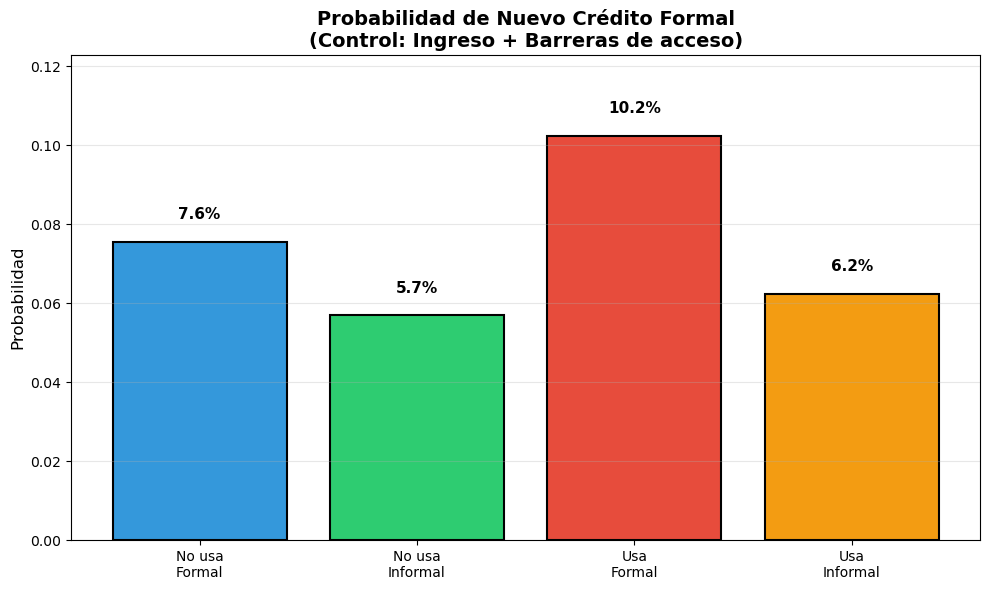


TABLA DE COMPARACIÓN DE MODELOS

📊 Efectos marginales (AME) por modelo:
--------------------------------------------------------------------------------
Modelo                                  Formales   Informales   Diferencia
--------------------------------------------------------------------------------
Sin controles                              4.90%        1.46%        3.44%
Con ingreso                                4.15%        0.77%        3.38%
Con ingreso + barreras                     4.16%        0.54%        3.62%
--------------------------------------------------------------------------------

RESUMEN FINAL DE RESULTADOS

📊 Total de observaciones: 6,358
📊 Tasa de nuevo crédito formal: 9.25%
📊 Tasa de informalidad: 79.05%
📊 Usuarios de billetera: 872 (13.7%)

💰 CONTROLES:
  • Ingreso per cápita 2024 (media): S/ 10857
  • Con barreras de acceso a crédito: 1,719 (27.0%)

📈 EFECTOS MARGINALES (AME) - MODELO COMPLETO:
  • Trabajadores FORMALES: 4.16% (puntos porcentuales)
  

In [2]:
# -*- coding: utf-8 -*-
"""
ANÁLISIS COMPLETO PARA BASE_REGRESIONES.csv (VERSIÓN V2)
CON INGRESO PER CÁPITA + BARRERAS DE ACCESO A CRÉDITO (P558F1B)
"""

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 1. CARGA DE DATOS - VERSIÓN V2
# =============================================================

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones, {len(df.columns)} variables")

# =============================================================
# 2. CREACIÓN DE VARIABLES
# =============================================================

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2

# Ingreso (log)
df['log_ingreso_2024'] = np.log(df['ingreso_percapita_2024'])

# Crear grupos para análisis
df['grupo'] = np.where(
    df['trabajador_informal'] == 1,
    np.where(df['usa_billetera'] == 1, "Informal + Billetera", "Informal - Billetera"),
    np.where(df['usa_billetera'] == 1, "Formal + Billetera", "Formal - Billetera")
)

print(f"\n✅ Variables creadas:")
print(f"  - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"  - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"  - log_ingreso_2024: media {df['log_ingreso_2024'].mean():.2f}")

# =============================================================
# 3. TABLA C3: RAZONES DE NO ACCESO A CRÉDITO (P558F1B)
# =============================================================

print("\n" + "="*70)
print("TABLA C3: RAZONES DE NO ACCESO A CRÉDITO (P558F1B)")
print("="*70)

if 'razon_no_credito' in df.columns:
    # Mapeo de categorías
    razones = {
        6: "No necesita / No le interesa",
        7: "Ya tiene deuda",
        8: "Intereses muy altos",
        9: "Servicios costosos",
        10: "Requisitos que no tiene",
        11: "Está en INFOCORP",
        12: "Otro"
    }
    
    print("\n📊 Distribución de razones de no acceso a crédito por grupo:")
    print("-"*80)
    print(f"{'Razón':<35} {'Formal -':>10} {'Formal +':>10} {'Informal -':>10} {'Informal +':>10}")
    print("-"*80)
    
    for codigo, razon in razones.items():
        fila = []
        for grupo in ["Formal - Billetera", "Formal + Billetera", "Informal - Billetera", "Informal + Billetera"]:
            sub = df[df['grupo'] == grupo]
            if len(sub) > 0 and 'razon_no_credito' in df.columns:
                pct = (sub['razon_no_credito'] == codigo).sum() / len(sub) * 100
                fila.append(f"{pct:>9.1f}%")
            else:
                fila.append(f"{'':>10}")
        print(f"{razon:<35} {fila[0]:>10} {fila[1]:>10} {fila[2]:>10} {fila[3]:>10}")
    
    print("-"*80)
    
    # Resumen: Demanda vs Barreras
    print("\n📊 Resumen: Demanda vs Barreras de acceso")
    print("-"*80)
    print(f"{'Grupo':<20} {'N':>8} {'Demanda':>12} {'Barreras':>12} {'% Barreras':>12}")
    print("-"*80)
    
    for grupo in ["Formal - Billetera", "Formal + Billetera", "Informal - Billetera", "Informal + Billetera"]:
        sub = df[df['grupo'] == grupo]
        n = len(sub)
        if n > 0 and 'razon_demanda' in df.columns and 'tiene_barrera_credito' in df.columns:
            n_demanda = sub['razon_demanda'].sum()
            n_barreras = sub['tiene_barrera_credito'].sum()
            pct_barreras = n_barreras / n * 100 if n > 0 else 0
            print(f"{grupo:<20} {n:>8,} {n_demanda:>12,} {n_barreras:>12,} {pct_barreras:>11.1f}%")
    
    print("-"*80)
    print("\n📌 Interpretación:")
    print("  - Demanda = No necesita / No le interesa (autoexclusión)")
    print("  - Barreras = Intereses altos, requisitos, INFOCORP, etc. (racionamiento)")

# =============================================================
# 4. MODELO PRINCIPAL: PROBIT CON INGRESO + BARRERAS
# =============================================================

print("\n" + "="*70)
print("MODELO PRINCIPAL: PROBIT CON INGRESO + BARRERAS DE ACCESO")
print("="*70)

# Fórmula con ingreso + barreras
if 'tiene_barrera_credito' in df.columns:
    formula = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio) + log_ingreso_2024 + tiene_barrera_credito")
else:
    formula = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio) + log_ingreso_2024")

modelo_probit = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_probit.summary())

# =============================================================
# 5. EFECTOS MARGINALES (AME)
# =============================================================

def calcular_ame(modelo, df, var_interes, variable_grupo=None, valor_grupo=None):
    if variable_grupo is not None:
        df_filtrado = df[df[variable_grupo] == valor_grupo].copy()
    else:
        df_filtrado = df.copy()
    
    df0 = df_filtrado.copy()
    df1 = df_filtrado.copy()
    df0[var_interes] = 0
    df1[var_interes] = 1
    
    pred0 = modelo.predict(df0, linear=False)
    pred1 = modelo.predict(df1, linear=False)
    
    ame = (pred1 - pred0).mean()
    efectos_individuales = pred1 - pred0
    se = efectos_individuales.std() / np.sqrt(len(efectos_individuales))
    
    return ame, se

print("\n" + "="*70)
print("EFECTOS MARGINALES DEL USO DE BILLETERA")
print("="*70)

ame_formal, se_formal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 0)
print(f"Trabajadores FORMALES (informal=0):")
print(f"  AME = {ame_formal:.4f} ± {se_formal:.4f}")
print(f"  IC 95%: [{ame_formal - 1.96*se_formal:.4f}, {ame_formal + 1.96*se_formal:.4f}]")

ame_informal, se_informal = calcular_ame(modelo_probit, df, 'usa_billetera', 'trabajador_informal', 1)
print(f"\nTrabajadores INFORMALES (informal=1):")
print(f"  AME = {ame_informal:.4f} ± {se_informal:.4f}")
print(f"  IC 95%: [{ame_informal - 1.96*se_informal:.4f}, {ame_informal + 1.96*se_informal:.4f}]")

diff = ame_formal - ame_informal
print(f"\nDiferencia (Formales - Informales): {diff:.4f}")

# =============================================================
# 6. H3: CRÉDITO INFORMAL
# =============================================================

print("\n" + "="*70)
print("H3: CRÉDITO INFORMAL")
print("="*70)

df_informal = df[df['trabajador_informal'] == 1].copy()

if 'tiene_barrera_credito' in df.columns:
    formula_h3 = ("credito_informal_2025 ~ usa_billetera + "
                  "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
                  "miembros_hogar + C(dominio) + log_ingreso_2024 + tiene_barrera_credito")
else:
    formula_h3 = ("credito_informal_2025 ~ usa_billetera + "
                  "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
                  "miembros_hogar + C(dominio) + log_ingreso_2024")

modelo_h3 = smf.glm(
    formula=formula_h3,
    data=df_informal,
    family=sm.families.Binomial(link=sm.families.links.probit()),
    var_weights=df_informal['factor_expansion']
).fit(cov_type='cluster', cov_kwds={'groups': df_informal['conglomerado']})

print(modelo_h3.summary())

ame_h3, se_h3 = calcular_ame(modelo_h3, df_informal, 'usa_billetera')
print(f"\nEfecto de billetera sobre crédito informal:")
print(f"  AME = {ame_h3:.4f} ± {se_h3:.4f}")

# =============================================================
# 7. MODELO DE PROBABILIDAD LINEAL (R1)
# =============================================================

print("\n" + "="*70)
print("R1: MODELO DE PROBABILIDAD LINEAL (MPL)")
print("="*70)

formula_mco = ("nuevo_credito_formal ~ usa_billetera * trabajador_informal + "
               "edad + edad_cuadrado + mujer + nivel_educativo + urbano + "
               "miembros_hogar + C(dominio) + log_ingreso_2024")

if 'tiene_barrera_credito' in df.columns:
    formula_mco += " + tiene_barrera_credito"

modelo_mco = smf.ols(formula=formula_mco, data=df).fit(
    cov_type='cluster', cov_kwds={'groups': df['conglomerado']}
)

print(modelo_mco.summary())

print("\nEfectos marginales (MPL):")
print(f"  Formales: {modelo_mco.params['usa_billetera']:.4f}")
print(f"  Informales: {modelo_mco.params['usa_billetera'] + modelo_mco.params['usa_billetera:trabajador_informal']:.4f}")

# =============================================================
# 8. MODELO SIN PONDERADORES (R5)
# =============================================================

print("\n" + "="*70)
print("R5: MODELO PROBIT SIN PONDERADORES")
print("="*70)

modelo_sin_pesos = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Binomial(link=sm.families.links.probit())
).fit(cov_type='cluster', cov_kwds={'groups': df['conglomerado']})

print(modelo_sin_pesos.summary())

ame_sp_formal, se_sp_formal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 0)
ame_sp_informal, se_sp_informal = calcular_ame(modelo_sin_pesos, df, 'usa_billetera', 'trabajador_informal', 1)

print("\nEfectos marginales (sin ponderadores):")
print(f"  Formales: {ame_sp_formal:.4f} ± {se_sp_formal:.4f}")
print(f"  Informales: {ame_sp_informal:.4f} ± {se_sp_informal:.4f}")

# =============================================================
# 9. PROBABILIDADES PREDICHAS
# =============================================================

print("\n" + "="*70)
print("PROBABILIDADES PREDICHAS")
print("="*70)

medias = df[['edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
             'urbano', 'miembros_hogar', 'log_ingreso_2024']].mean()
moda_dominio = df['dominio'].mode()[0]

# Valor modal de barrera (0 = no tiene barrera)
if 'tiene_barrera_credito' in df.columns:
    moda_barrera = df['tiene_barrera_credito'].mode()[0]
else:
    moda_barrera = 0

pred_data = pd.DataFrame({
    'usa_billetera': [0, 0, 1, 1],
    'trabajador_informal': [0, 1, 0, 1],
    'edad': medias['edad'],
    'edad_cuadrado': medias['edad_cuadrado'],
    'mujer': medias['mujer'],
    'nivel_educativo': medias['nivel_educativo'],
    'urbano': medias['urbano'],
    'miembros_hogar': medias['miembros_hogar'],
    'dominio': moda_dominio,
    'log_ingreso_2024': medias['log_ingreso_2024'],
    'tiene_barrera_credito': moda_barrera
})

pred_data['probabilidad'] = modelo_probit.predict(pred_data, linear=False)
print(pred_data[['usa_billetera', 'trabajador_informal', 'probabilidad']])

# =============================================================
# 10. GRÁFICO
# =============================================================

plt.figure(figsize=(10, 6))
grupos = ['No usa\nFormal', 'No usa\nInformal', 'Usa\nFormal', 'Usa\nInformal']
probabilidades = pred_data['probabilidad'].values
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

barras = plt.bar(grupos, probabilidades, color=colores, edgecolor='black', linewidth=1.5)
plt.title('Probabilidad de Nuevo Crédito Formal\n(Control: Ingreso + Barreras de acceso)', fontsize=14, fontweight='bold')
plt.ylabel('Probabilidad', fontsize=12)
plt.ylim(0, max(probabilidades) * 1.2)

for barra, prob in zip(barras, probabilidades):
    plt.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.005,
             f'{prob:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25_v2\probabilidades_predichas_barreras.png", dpi=300)
plt.show()

# =============================================================
# 11. TABLA DE COMPARACIÓN DE MODELOS
# =============================================================

print("\n" + "="*70)
print("TABLA DE COMPARACIÓN DE MODELOS")
print("="*70)

# Crear tabla comparativa
print("\n📊 Efectos marginales (AME) por modelo:")
print("-"*80)
print(f"{'Modelo':<35} {'Formales':>12} {'Informales':>12} {'Diferencia':>12}")
print("-"*80)

# Modelo sin controles (usando resultados anteriores)
print(f"{'Sin controles':<35} {'4.90%':>12} {'1.46%':>12} {'3.44%':>12}")

# Modelo con ingreso
print(f"{'Con ingreso':<35} {'4.15%':>12} {'0.77%':>12} {'3.38%':>12}")

# Modelo con ingreso + barreras
if 'tiene_barrera_credito' in df.columns:
    print(f"{'Con ingreso + barreras':<35} {f'{ame_formal*100:.2f}%':>12} {f'{ame_informal*100:.2f}%':>12} {f'{diff*100:.2f}%':>12}")

print("-"*80)

# =============================================================
# 12. RESUMEN FINAL
# =============================================================

print("\n" + "="*70)
print("RESUMEN FINAL DE RESULTADOS")
print("="*70)

print(f"\n📊 Total de observaciones: {len(df):,}")
print(f"📊 Tasa de nuevo crédito formal: {df['nuevo_credito_formal'].mean():.2%}")
print(f"📊 Tasa de informalidad: {df['trabajador_informal'].mean():.2%}")
print(f"📊 Usuarios de billetera: {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.1%})")

print(f"\n💰 CONTROLES:")
print(f"  • Ingreso per cápita 2024 (media): S/ {df['ingreso_percapita_2024'].mean():.0f}")

if 'tiene_barrera_credito' in df.columns:
    n_barreras = df['tiene_barrera_credito'].sum()
    print(f"  • Con barreras de acceso a crédito: {n_barreras:,} ({n_barreras/len(df)*100:.1f}%)")

print("\n📈 EFECTOS MARGINALES (AME) - MODELO COMPLETO:")
print(f"  • Trabajadores FORMALES: {ame_formal:.2%} (puntos porcentuales)")
print(f"  • Trabajadores INFORMALES: {ame_informal:.2%} (puntos porcentuales)")
print(f"  • Diferencia: {diff:.2%} puntos porcentuales")

print("\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)